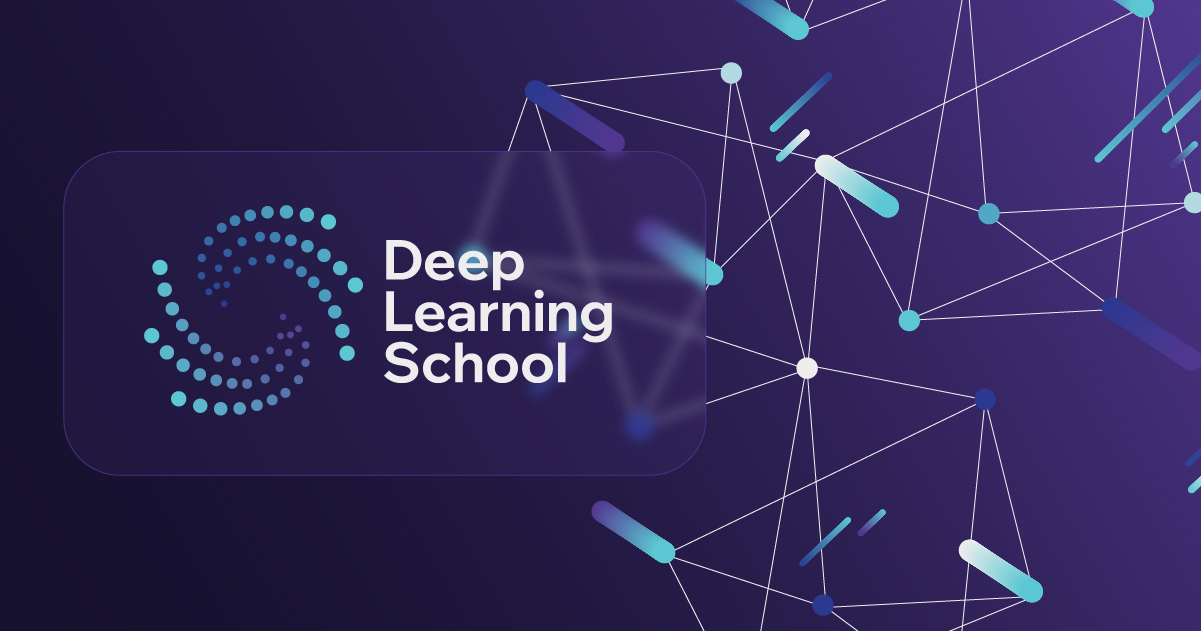

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Полносвязные и свёрточные нейронные сети</b></h1>



В этом занятии вам предстоит потренироваться построению нейронных сетей с помощью библиотеки Pytorch. Делать мы это будем на нескольких датасетах.








In [1]:
import random

import numpy as np
import seaborn as sns
import torch
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

sns.set(style="darkgrid", font_scale=1.4)

In [2]:
# Reduce stochasticity

SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

In [3]:
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

# Часть 1. Датасет moons

Давайте сгенерируем датасет и посмотрим на него!

In [20]:
X, y = make_moons(n_samples=10000, random_state=42, noise=0.1)

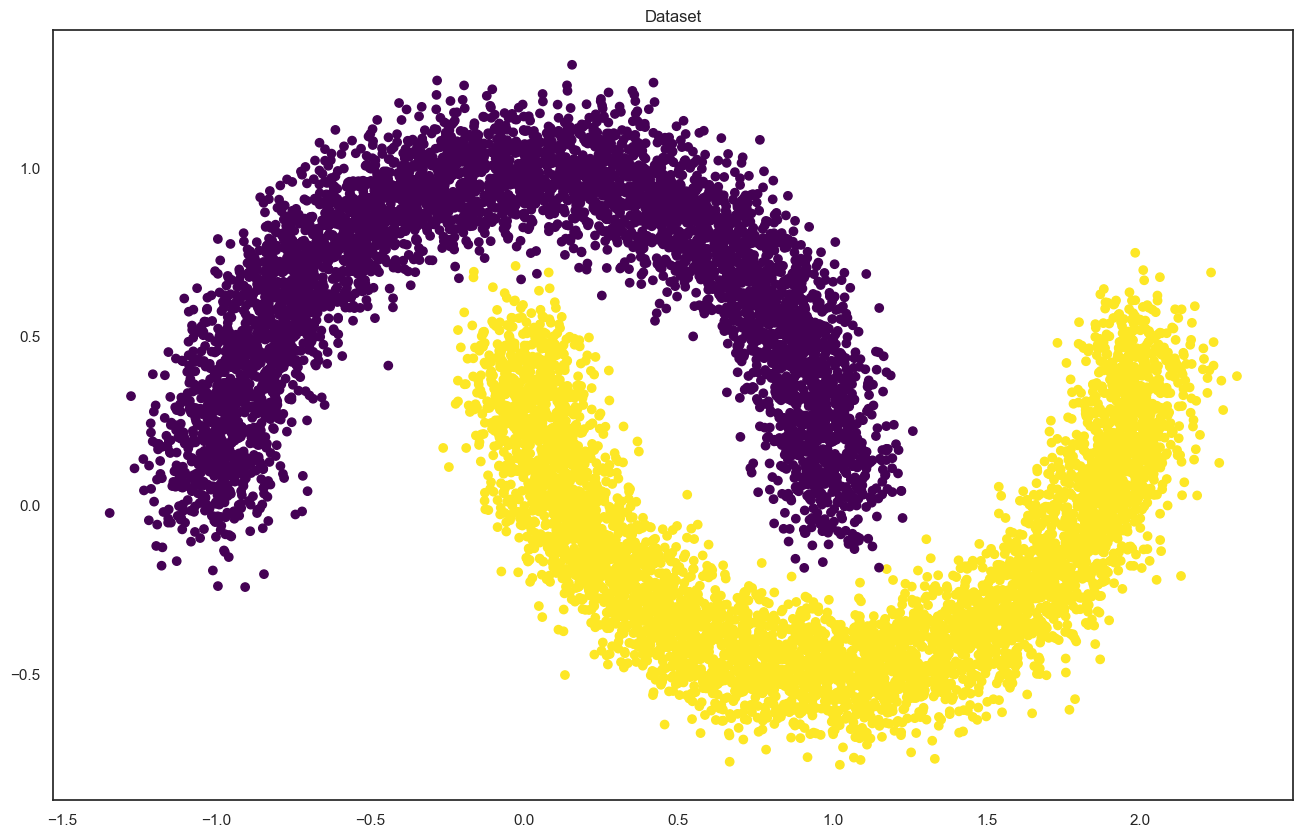

In [21]:
plt.figure(figsize=(16, 10))
plt.title("Dataset")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.show()

Сделаем train/test split

In [22]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

### Загрузка данных
В PyTorch загрузка данных как правило происходит налету (иногда датасеты не помещаются в оперативную память). Для этого используются две сущности `Dataset` и `DataLoader`.

1.   `Dataset` загружает каждый объект по отдельности.

2.   `DataLoader` группирует объекты из `Dataset` в батчи.

Так как наш датасет достаточно маленький мы будем использовать `TensorDataset`. Все, что нам нужно, это перевести из массива numpy в тензор с типом `torch.float32`.

### Задание 1. Создайте тензоры с обучающими и тестовыми данными

In [23]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)

Создаем `Dataset` и `DataLoader`.

In [24]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_dataloader = DataLoader(train_dataset, batch_size=128)
val_dataloader = DataLoader(val_dataset, batch_size=128)

In [15]:
def dataloader_info(dataloader: DataLoader):
    '''
    Выводит информацию о DataLoader
    :param dataloader:
    :return:
    '''
    global num_samples, batch, _
    num_samples = len(dataloader.dataset)
    print(f"Количество элементов в наборе данных: {num_samples}")
    batch_size = dataloader.batch_size
    print(f"Размер батча: {batch_size}")
    # Размерность данных и типы данных
    for batch in dataloader:
        inputs, labels = batch
        print(f"Размерность входных данных в батче: {inputs.shape}")
        print(f"Размерность меток в батче: {labels.shape}")
        print(f"Тип входных данных: {inputs.dtype}")
        print(f"Тип меток: {labels.dtype}")
        break
    # Уникальные значения меток
    unique_labels = set()
    for batch in dataloader:
        _, labels = batch
        labels_flat = labels.flatten().tolist()
        unique_labels.update(labels_flat)
    print(f"Уникальные значения меток: {unique_labels}")
    num_batches = (num_samples + batch_size - 1) // batch_size
    print(f"Количество батчей: {num_batches}")


In [10]:

dataloader_info(train_dataloader)

Количество элементов в наборе данных: 7500
Размер батча: 128
Размерность входных данных в батче: torch.Size([128, 2])
Размерность меток в батче: torch.Size([128, 1])
Тип входных данных: torch.float32
Тип меток: torch.float32
Уникальные значения меток: {0.0, 1.0}
Количество батчей: 59


## Logistic regression is my profession

**Напоминание**
Давайте вспоним, что происходит в логистической регрессии. На входе у нас есть матрица объект-признак X и столбец-вектор $y$ – метки из $\{0, 1\}$ для каждого объекта. Мы хотим найти такую матрицу весов $W$ и смещение $b$ (bias), что наша модель $XW + b$ будет каким-то образом предсказывать класс объекта. Как видно на выходе наша модель может выдавать число в интервале от $(-\infty;\infty)$. Этот выход как правило называют "логитами" (logits). Нам необходимо перевести его на интервал от $[0;1]$ для того, чтобы он выдавал нам вероятность принадлежности объекта к классу один, также лучше, чтобы эта функция была монотонной, быстро считалась, имела производную и на $-\infty$ имела значение $0$, а на $+\infty$ имела значение $1$. Такой класс функций называется сигмоидой. Чаще всего в качестве сигмоида берут:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}.
$$

### Задание 2 . Реализация логистической регрессии

Вам необходимо написать модуль на PyTorch реализующий $logits = XW + b$, где $W$ и $b$ – параметры (`nn.Parameter`) модели. Иначе говоря, здесь мы реализуем своими руками модуль `nn.Linear` (в этом пункте его использование запрещено). Инициализируйте веса нормальным распределением (`torch.randn`).

In [25]:
class LinearRegression(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = bias
        if bias:
            self.bias_term = nn.Parameter(torch.randn(out_features))
        else:
            self.register_parameter('bias_term', None)

    def forward(self, x):
        x = torch.matmul(x, self.weights.t())
        if self.bias:
            x += self.bias_term
        return x

In [26]:
linear_regression = LinearRegression(2, 1)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.05)

**Вопрос 1.** Сколько обучаемых параметров у получившейся модели? Имеется в виду суммарное количество отдельных числовых переменных, а не количество тензоров.

In [13]:
def count_parameters(model):
    sum = 0
    for name, param in model.named_parameters():
        if param.requires_grad:  # Учитываем только обучаемые параметры
            print(f"{name}: {param.numel()} параметров")
            sum += param.numel()
    print(f"итого: {sum} параметров")

In [14]:
count_parameters(linear_regression)

weights: 2 параметров
bias_term: 1 параметров
итого: 3 параметров


In [15]:
list(linear_regression.parameters())

[Parameter containing:
 tensor([[0.2345, 0.2303]], requires_grad=True),
 Parameter containing:
 tensor([-1.1229], requires_grad=True)]

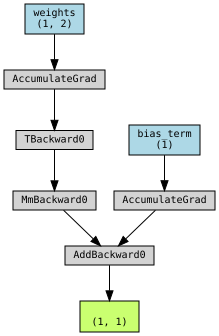

In [16]:
from torchviz import make_dot

x = torch.randn(1, 2)
y = linear_regression(x)
make_dot(y, params=dict(linear_regression.named_parameters()), show_attrs=False, show_saved=False)

**Ответ:** 3 параметра

### Train loop

Перейдём непосредственно к обучению.

Вот псевдокод, который поможет вам разобраться в том, что происходит во время обучения

```python
for epoch in range(max_epochs):  # <----------- итерируемся по датасету несколько раз
    for x_batch, y_batch in dataset:  # <------ итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
        optimizer.zero_grad()  # <------------- обнуляем градиенты модели
        outp = model(x_batch)  # <------------- получаем "логиты" из модели
        loss = loss_func(outp, y_batch)  # <--- считаем "лосс" для логистической регрессии
        loss.backward()  # <------------------- считаем градиенты
        optimizer.step()  # <------------------ делаем шаг градиентного спуска
        if convergence:  # <------------------- в случае сходимости выходим из цикла
            break
```

В коде ниже добавлено логирование `accuracy` и `loss`.

### Задание 3. Реализация цикла обучения

In [27]:
# Параметры обучения
tol = 1e-3
losses = []
max_epochs = 500
prev_weights = torch.zeros_like(linear_regression.weights)
stop_it = False
criterion = nn.BCEWithLogitsLoss()  # Бинарная кросс-энтропия с логитами

for epoch in range(max_epochs):
    for it, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()

        # Прямой проход
        outp = linear_regression(X_batch)
        loss = criterion(outp, y_batch)
        loss.backward()
        losses.append(loss.detach().flatten()[0])
        optimizer.step()

        probabilities = torch.sigmoid(outp)
        preds = (probabilities > 0.5).type(torch.long)

        batch_acc = (preds.flatten() == y_batch).type(torch.float32).sum() / y_batch.size(0)

        if (it + epoch * len(train_dataloader)) % 100 == 0:
            print(f"Iteration: {it + epoch * len(train_dataloader)}\nBatch accuracy: {batch_acc}")

        current_weights = linear_regression.weights.detach().clone()
        if (prev_weights - current_weights).abs().max() < tol:
            print(f"\nIteration: {it + epoch * len(train_dataloader)}. Convergence. Stopping iterations.")
            stop_it = True
            break
        prev_weights = current_weights

    if stop_it:
        break

Iteration: 0
Batch accuracy: 62.875
Iteration: 100
Batch accuracy: 65.21875
Iteration: 200
Batch accuracy: 64.0
Iteration: 300
Batch accuracy: 65.09375
Iteration: 400
Batch accuracy: 63.953125
Iteration: 500
Batch accuracy: 64.0625
Iteration: 600
Batch accuracy: 66.0625

Iteration: 641. Convergence. Stopping iterations.


**Вопрос 2.** Сколько итераций потребовалось, чтобы алгоритм сошелся? (ваш ответ может варьироваться в зависимости от запуска)


**Ответ:** Потребовалось 523 итерации для стабилизации алгоритма

### Визуализируем результаты

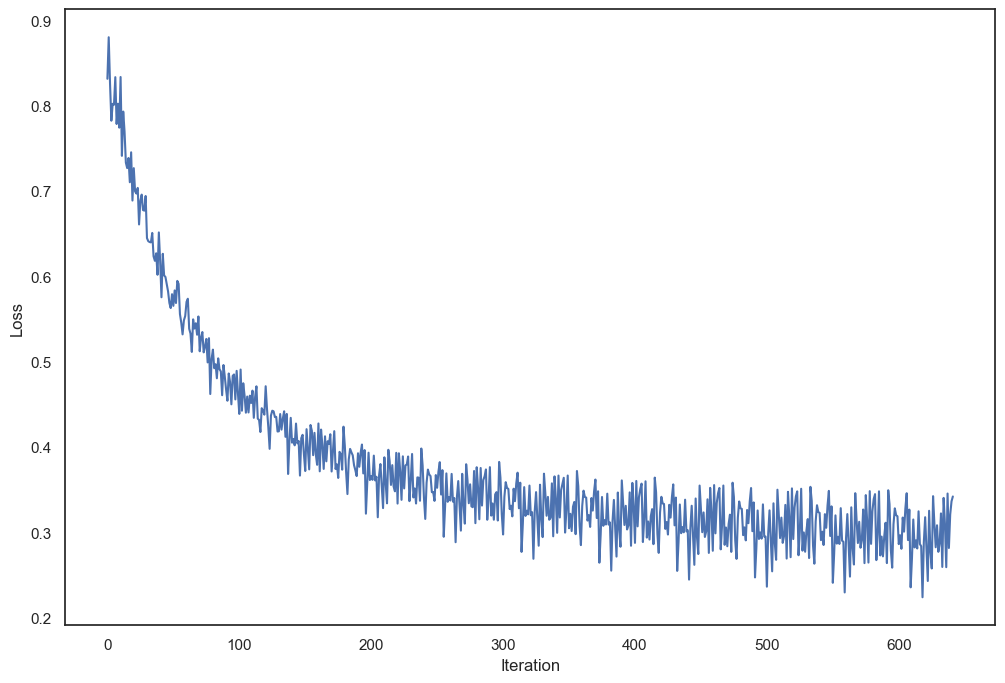

In [28]:
plt.figure(figsize=(12, 8))
plt.plot(range(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

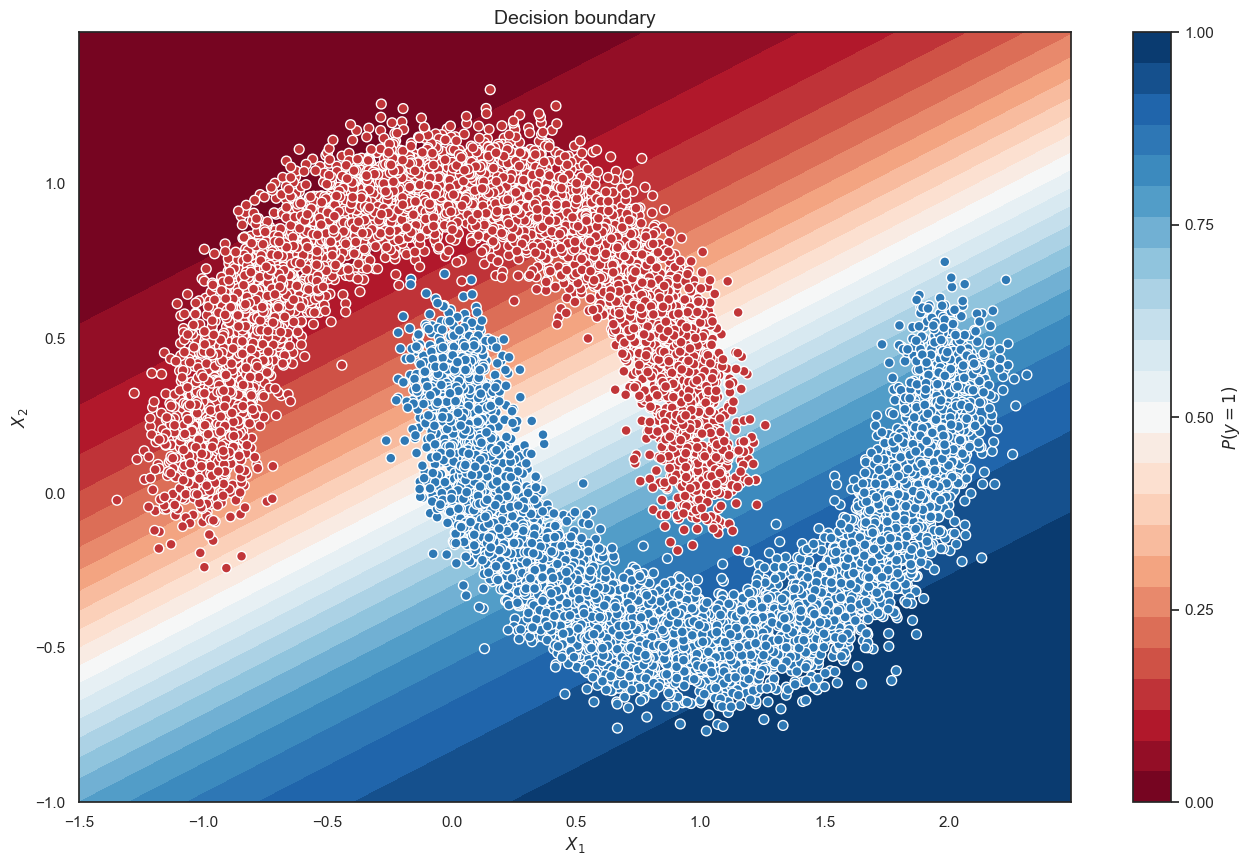

In [30]:
import numpy as np

sns.set(style="white")

xx, yy = np.mgrid[-1.5:2.5:.01, -1.:1.5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
batch = torch.from_numpy(grid).type(torch.float32)
with torch.no_grad():
    probs = torch.sigmoid(linear_regression(batch).reshape(xx.shape))
    probs = probs.numpy().reshape(xx.shape)

f, ax = plt.subplots(figsize=(16, 10))
ax.set_title("Decision boundary", fontsize=14)
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[100:, 0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(xlabel="$X_1$", ylabel="$X_2$")
plt.show()

### Задание 4. Реализуйте predict и посчитайте accuracy на test.

In [35]:
@torch.no_grad()
def predict(dataloader, model):
    model.eval()
    predictions = np.array([])
    for x_batch, _ in dataloader:
        logits = model(x_batch).flatten()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).type(torch.long)
        predictions = np.hstack((predictions, preds.numpy().flatten()))
    return predictions.flatten()

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
y_pred = predict(val_dataloader, linear_regression)

# Истинные метки (нужно собрать их из test_dataloader)
y_true = np.array([])
for _, y_batch in val_dataloader:
    y_true = np.hstack((y_true, y_batch.numpy().flatten()))

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy on test set: {accuracy:.4f}")

Accuracy on test set: 0.8728


**Вопрос 3**

Какое `accuracy` получается после обучения? (ваш ответ может варьироваться в зависимости от запуска)


**Ответ:** 0.8728

# Часть 2. Датасет MNIST
Датасет MNIST содержит рукописные цифры. Загрузим датасет и создадим DataLoader-ы. Пример можно найти в семинаре по полносвязным нейронным сетям.

In [10]:
import os

root = '..\\data'

In [11]:
os.listdir(root)

['MNIST']

In [12]:
from torchvision.datasets import MNIST
from torchvision import transforms as tfs

data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

batch_size = 10
# install for train and test
train_dataset = MNIST(root, train=True, transform=data_tfs, download=True)
val_dataset = MNIST(root, train=False, transform=data_tfs, download=True)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                                               num_workers=2)
valid_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                               num_workers=2)

classes = tuple(str(i) for i in range(10))

In [13]:
image, label = train_dataset[0]
print('размерность', image.shape, label)

размерность torch.Size([1, 28, 28]) 5


In [16]:
dataloader_info(train_dataloader)

Количество элементов в наборе данных: 60000
Размер батча: 10
Размерность входных данных в батче: torch.Size([10, 1, 28, 28])
Размерность меток в батче: torch.Size([10])
Тип входных данных: torch.float32
Тип меток: torch.int64
Уникальные значения меток: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Количество батчей: 6000


## Часть 2.1. Полносвязные нейронные сети
Сначала решим MNIST с помощью полносвязной нейронной сети.

### Задание 5. Простая полносвязная нейронная сеть

Создайте полносвязную нейронную сеть с помощью класса Sequential. Сеть состоит из:
* Уплощения матрицы в вектор (nn.Flatten);
* Двух скрытых слоёв из 128 нейронов с активацией nn.ELU;
* Выходного слоя с 10 нейронами.


In [17]:
activation = nn.ELU()

In [18]:
def create_model_by_activation(f_activation=nn.ELU()):
    model = nn.Sequential(
        nn.Flatten(),  # Уплощение матрицы в вектор
        nn.Linear(in_features=28 * 28, out_features=128),
        activation,
        nn.Linear(in_features=128, out_features=128),
        activation,
        nn.Linear(in_features=128, out_features=10))
    return model

In [19]:

model = create_model_by_activation(activation)
# Пример вывода структуры модели
print(model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ELU(alpha=1.0)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ELU(alpha=1.0)
  (5): Linear(in_features=128, out_features=10, bias=True)
)


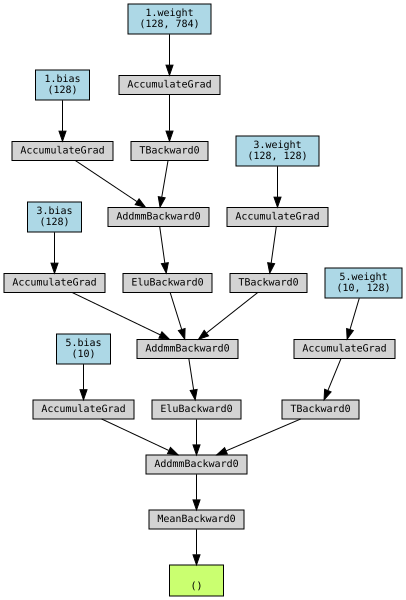

In [59]:
from torchviz import make_dot

x = torch.randn(1, 1, 28, 28)  # Батч из одного изображения 28x28
y = model(x)
make_dot(y.mean(), params=dict(model.named_parameters()), show_attrs=False, show_saved=False)

In [60]:
count_parameters(model)

1.weight: 100352 параметров
1.bias: 128 параметров
3.weight: 16384 параметров
3.bias: 128 параметров
5.weight: 1280 параметров
5.bias: 10 параметров
итого: 118282 параметров


Задайте лосс для обучения (кросс-энтропия).

Вспомним, что такое кросс-энтропийная функция потерь:

$$
L = -\frac{1}{N} \sum_{n=1}^{N} \sum_{i=1}^{C} y_{ni} \log(\hat{y}_{ni})
$$

где:
- $N$ — количество объектов в выборке,
- $C$ — количество классов,
- $y_{ni}$ — истинная метка (one-hot представление),
- $\hat{y}_{ni}$ — предсказанная вероятность модели для класса $i$ на примере $n$.

***Пример расчета***

Рассмотрим пример расчета кросс-энтропийной функции потерь для задачи многоклассовой классификации с 10 классами. Предположим, что у нас есть один объект, истинный класс которого известен, а модель выдала свои предсказания в виде вероятностей для каждого класса.

Пусть объект является цифрой 2. Тогда:
     $$
     y = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
     $$

Пусть модель выдала следующие вероятности для 10 классов:  
     $$
     \hat{y} = [0.1, 0.05, 0.6, 0.15, 0.05, 0.02, 0.01, 0.01, 0.01, 0.0]
     $$

$$
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$



Только один элемент $y_i$ равен 1, остальные равны 0. Поэтому:

$
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i) = - y_2 \cdot log(\hat{y}_2) = - 1 \cdot log(0.6) \approx 0.51
$

### Train loop (seriously)

Давайте разберемся с кодом ниже, который подойдет для 90% задач в будущем.


```python
for epoch in range(max_epochs):  # <--------------- итерируемся по датасету несколько раз
    for k, dataloader in loaders.items():  # <----- несколько dataloader для train / valid / test
        for x_batch, y_batch in dataloader:  # <--- итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
            if k == "train":
                model.train()  # <------------------ переводим модель в режим train
                optimizer.zero_grad()  # <--------- обнуляем градиенты модели
                outp = model(x_batch)
                loss = criterion(outp, y_batch) # <-считаем "лосс" для логистической регрессии
                loss.backward()  # <--------------- считаем градиенты
                optimizer.step()  # <-------------- делаем шаг градиентного спуска
            else:  # <----------------------------- test/eval
                model.eval()  # <------------------ переводим модель в режим eval
                with torch.no_grad():  # <--------- НЕ считаем градиенты
                    outp = model(x_batch)  # <------------- получаем "логиты" из модели
            count_metrics(outp, y_batch)  # <-------------- считаем метрики
```

### Задание 6. Дополните цикл обучения.

In [20]:
loaders = {"train": train_dataloader, "valid": valid_dataloader}

In [21]:
list(loaders.items())

[('train', <torch.utils.data.dataloader.DataLoader at 0x16f6dbf3d40>),
 ('valid', <torch.utils.data.dataloader.DataLoader at 0x16f67909ca0>)]

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [23]:
def train_model(model, loaders, max_epochs=10):
    '''
    Обучает модель
    :param model: Модель в формате Torch
    :param loaders: Словарь загрузчиков train, valid
    :param max_epochs:
    :return: accuracy массив
    '''

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    max_epochs = max_epochs
    accuracy = {"train": [], "valid": []}
    for epoch in range(max_epochs):
        for k, dataloader in loaders.items():
            epoch_correct = 0
            epoch_all = 0

            if k == "train":
                model.train()  # Устанавливаем модель в режим обучения
            else:
                model.eval()  # Устанавливаем модель в режим оценки
            n_batch = 0
            for x_batch, y_batch in dataloader:
                if k == "train":
                    optimizer.zero_grad()  # Обнуляем градиенты
                    outp = model(x_batch)
                else:
                    with torch.no_grad():  # Отключаем вычисление градиентов для валидации
                        outp = model(x_batch)

                preds = outp.argmax(-1)  # Получаем предсказания
                correct = (preds == y_batch).sum()  # Считаем количество правильных предсказаний
                epoch_correct += correct.item()
                epoch_all += y_batch.size(0)

                if k == "train":
                    loss = criterion(outp, y_batch)  # Вычисляем потери
                    loss.backward()  # Обратный проход
                    optimizer.step()  # Обновляем веса
                n_batch += 1
                if n_batch % 1000 == 0:
                    print(f"Epoch: {epoch + 1}, Batch: {n_batch}/{len(dataloader)}, Loss: {loss.item()}")

            if k == "train":
                print(f"Epoch: {epoch + 1}")
            print(f"Loader: {k}. Accuracy: {epoch_correct / epoch_all}")
            accuracy[k].append(epoch_correct / epoch_all)
    return accuracy


In [85]:
model = create_model_by_activation()

In [86]:
accuracy = train_model(model, loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.33876660466194153
Epoch: 1, Batch: 2000/6000, Loss: 0.10969160497188568
Epoch: 1, Batch: 3000/6000, Loss: 0.3364497721195221
Epoch: 1, Batch: 4000/6000, Loss: 0.013418339192867279
Epoch: 1, Batch: 5000/6000, Loss: 0.03128763288259506
Epoch: 1, Batch: 6000/6000, Loss: 0.3191685080528259
Epoch: 1
Loader: train. Accuracy: 0.9131166666666667
Epoch: 1, Batch: 1000/1000, Loss: 0.3191685080528259
Loader: valid. Accuracy: 0.9412
Epoch: 2, Batch: 1000/6000, Loss: 0.04486294090747833
Epoch: 2, Batch: 2000/6000, Loss: 0.01754613220691681
Epoch: 2, Batch: 3000/6000, Loss: 0.014875678345561028
Epoch: 2, Batch: 4000/6000, Loss: 0.05036791041493416
Epoch: 2, Batch: 5000/6000, Loss: 0.006434209644794464
Epoch: 2, Batch: 6000/6000, Loss: 0.2532861828804016
Epoch: 2
Loader: train. Accuracy: 0.95415
Epoch: 2, Batch: 1000/1000, Loss: 0.2532861828804016
Loader: valid. Accuracy: 0.9583
Epoch: 3, Batch: 1000/6000, Loss: 0.032605744898319244
Epoch: 3, Batch: 2000/6000, Loss

{'train': [0.9131166666666667,
  0.95415,
  0.9642,
  0.9688666666666667,
  0.9723833333333334,
  0.97455,
  0.9764666666666667,
  0.97705,
  0.9793833333333334,
  0.9797833333333333],
 'valid': [0.9412,
  0.9583,
  0.9532,
  0.9647,
  0.9678,
  0.9687,
  0.9683,
  0.9679,
  0.9685,
  0.9681]}

In [84]:
accuracy

0.8728

In [91]:
# Предположим, что у вас есть valid_loader
valid_loader = loaders['valid']

# Преобразуем DataLoader в итератор
valid_iter = iter(valid_loader)

# Получаем случайный батч
x_batch, y_batch = next(valid_iter)

# Выбираем случайный индекс в батче
random_index = random.randint(0, len(x_batch) - 1)

# Получаем случайный пример и его метку
random_example = x_batch[random_index]
random_label = y_batch[random_index]

# Если данные нормализованы или требуют дополнительной обработки, их можно преобразовать
# Например, для изображений:
# random_example = random_example.permute(1, 2, 0)  # Если это изображение (C, H, W) -> (H, W, C)
# random_example = random_example.numpy()  # Преобразуем в numpy для визуализации

print(f"Случайный пример: {random_example}")
print(f"Метка: {random_label}")

Случайный пример: tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1

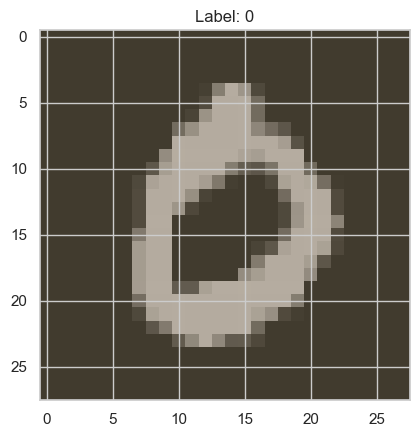

In [89]:
import matplotlib.pyplot as plt

# Преобразуем тензор изображения в формат (H, W, C)
random_example = random_example.permute(1, 2, 0)

# Если изображение нормализовано, отмените нормализацию
# Например, если использовались mean и std:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
random_example = random_example * std + mean

# Преобразуем в numpy и отобразим
random_example = random_example.numpy()
plt.imshow(random_example)
plt.title(f"Label: {random_label.item()}")
plt.show()

In [ ]:

# Предположим, что у вас есть valid_loader и обученная модель
valid_loader = loaders['valid']

# Преобразуем DataLoader в итератор
valid_iter = iter(valid_loader)

# Получаем случайный батч
x_batch, y_batch = next(valid_iter)

# Выбираем случайный индекс в батче
random_index = random.randint(0, len(x_batch) - 1)

# Получаем случайный пример и его истинную метку
random_example = x_batch[random_index]
true_label = y_batch[random_index]

In [92]:

# Переводим модель в режим оценки
model.eval()

# Отключаем вычисление градиентов
with torch.no_grad():
    # Добавляем размерность батча (модель ожидает input с размерностью [batch_size, ...])
    random_example = random_example.unsqueeze(0)

    # Получаем предсказание модели
    output = model(random_example)

    # Преобразуем выход модели в метку (для классификации)
    predicted_label = output.argmax(dim=1).item()

# Выводим результаты
print(f"Случайный пример: {random_example}")
print(f"Истинная метка: {true_label.item()}")
print(f"Предсказанная метка: {predicted_label}")

Случайный пример: tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.000

### Задание 7. Протестируйте разные функции активации.
Попробуйте разные функции активации. Для каждой функции активации посчитайте массив validation accuracy. Лучше реализовать это в виде функции, берущей на вход активацию и получающей массив из accuracies.

Функции активации добавляют ***нелинейность в модель***, что позволяет сети решать сложные задачи, такие как классификация и регрессия. Без функций активации нейронная сеть была бы линейной моделью, так как ***композиция линейных преобразований*** это ***линейное преобразование***.

**ReLU (Rectified Linear Unit)**
   - Формула: $ f(x) = \max(0, x) $
   - Диапазон значений: $ [0, \infty) $

**Leaky ReLU**
   - Формула: $ f(x) = \max(\alpha x, x) $, где $ \alpha $ — маленькое положительное число (обычно $ \alpha = 0.01 $).
   - Диапазон значений: $ (-\infty, \infty) $

**Exponential Linear Unit (ELU)**
   - Формула:
   $f(x) = $
     \begin{cases}
     x & \text{если } x > 0 \\
     \alpha (e^x - 1) & \text{если } x \leq 0
     \end{cases}
   - Диапазон значений:  $ (-\alpha, \infty) $

**Линейная функция активации**
   - Формула: $ f(x) = x $
   - Диапазон значений: $ (-\infty, \infty) $

   Обратите внимание, что данная функция активации **не добавляет** нелинейности.

In [ ]:
elu_accuracy = accuracy["valid"]

In [ ]:
# YOUR CODE. Do the same thing with other activations (it's better to wrap into a function that returns a list of accuracies)

def test_activation_function(activation):

#YOUR CODE

In [24]:
model_plain = create_model_by_activation(nn.Identity())
plain_accuracy=train_model(model_plain,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.13185220956802368
Epoch: 1, Batch: 2000/6000, Loss: 0.005237231496721506
Epoch: 1, Batch: 3000/6000, Loss: 0.13641254603862762
Epoch: 1, Batch: 4000/6000, Loss: 0.055338840931653976
Epoch: 1, Batch: 5000/6000, Loss: 0.025417625904083252
Epoch: 1, Batch: 6000/6000, Loss: 0.3420965373516083
Epoch: 1
Loader: train. Accuracy: 0.9129333333333334
Epoch: 1, Batch: 1000/1000, Loss: 0.3420965373516083
Loader: valid. Accuracy: 0.9467
Epoch: 2, Batch: 1000/6000, Loss: 0.15803687274456024
Epoch: 2, Batch: 2000/6000, Loss: 0.054846324026584625
Epoch: 2, Batch: 3000/6000, Loss: 0.011211668141186237
Epoch: 2, Batch: 4000/6000, Loss: 0.054722003638744354
Epoch: 2, Batch: 5000/6000, Loss: 0.15211215615272522
Epoch: 2, Batch: 6000/6000, Loss: 0.18232789635658264
Epoch: 2
Loader: train. Accuracy: 0.95405
Epoch: 2, Batch: 1000/1000, Loss: 0.18232789635658264
Loader: valid. Accuracy: 0.9553
Epoch: 3, Batch: 1000/6000, Loss: 0.14760389924049377
Epoch: 3, Batch: 2000/6000,

In [25]:
model_ReLU = create_model_by_activation(nn.ReLU())
ReLU_accuracy=train_model(model_plain,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.051403820514678955
Epoch: 1, Batch: 2000/6000, Loss: 0.0005159859429113567
Epoch: 1, Batch: 3000/6000, Loss: 0.0026117574889212847
Epoch: 1, Batch: 4000/6000, Loss: 0.8695634007453918
Epoch: 1, Batch: 5000/6000, Loss: 0.9273043870925903
Epoch: 1, Batch: 6000/6000, Loss: 0.0013439717004075646
Epoch: 1
Loader: train. Accuracy: 0.9809166666666667
Epoch: 1, Batch: 1000/1000, Loss: 0.0013439717004075646
Loader: valid. Accuracy: 0.9723
Epoch: 2, Batch: 1000/6000, Loss: 0.0002879665116779506
Epoch: 2, Batch: 2000/6000, Loss: 0.005034246481955051
Epoch: 2, Batch: 3000/6000, Loss: 7.807992915331852e-06
Epoch: 2, Batch: 4000/6000, Loss: 1.5497164440603228e-06
Epoch: 2, Batch: 5000/6000, Loss: 0.00011820123472716659
Epoch: 2, Batch: 6000/6000, Loss: 0.0007814974524080753
Epoch: 2
Loader: train. Accuracy: 0.9814333333333334
Epoch: 2, Batch: 1000/1000, Loss: 0.0007814974524080753
Loader: valid. Accuracy: 0.968
Epoch: 3, Batch: 1000/6000, Loss: 5.459719886857783e-

In [26]:
model_LeakyReLU = create_model_by_activation(nn.LeakyReLU())
LeakyReLU_accuracy=train_model(model_plain,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 6.472974291682476e-06
Epoch: 1, Batch: 2000/6000, Loss: 7.157416257541627e-05
Epoch: 1, Batch: 3000/6000, Loss: 7.6054484452470206e-06
Epoch: 1, Batch: 4000/6000, Loss: 3.0636317660537316e-06
Epoch: 1, Batch: 5000/6000, Loss: 4.211208943161182e-05
Epoch: 1, Batch: 6000/6000, Loss: 1.192092824453539e-08
Epoch: 1
Loader: train. Accuracy: 0.9860666666666666
Epoch: 1, Batch: 1000/1000, Loss: 1.192092824453539e-08
Loader: valid. Accuracy: 0.9746
Epoch: 2, Batch: 1000/6000, Loss: 0.0020654243417084217
Epoch: 2, Batch: 2000/6000, Loss: 0.006951123476028442
Epoch: 2, Batch: 3000/6000, Loss: 0.0007422893540933728
Epoch: 2, Batch: 4000/6000, Loss: 0.0011938194511458278
Epoch: 2, Batch: 5000/6000, Loss: 0.855560302734375
Epoch: 2, Batch: 6000/6000, Loss: 1.0728830091011332e-07
Epoch: 2
Loader: train. Accuracy: 0.9864166666666667
Epoch: 2, Batch: 1000/1000, Loss: 1.0728830091011332e-07
Loader: valid. Accuracy: 0.9697
Epoch: 3, Batch: 1000/6000, Loss: 0.00011793211

In [27]:
model_ELU = create_model_by_activation(nn.ELU())
ELU_accuracy=train_model(model_plain,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 2.6821762730833143e-06
Epoch: 1, Batch: 2000/6000, Loss: 0.0
Epoch: 1, Batch: 3000/6000, Loss: 2.1457648813338892e-07
Epoch: 1, Batch: 4000/6000, Loss: 0.1272178590297699
Epoch: 1, Batch: 5000/6000, Loss: 0.0
Epoch: 1, Batch: 6000/6000, Loss: 0.06989922374486923
Epoch: 1
Loader: train. Accuracy: 0.9882
Epoch: 1, Batch: 1000/1000, Loss: 0.06989922374486923
Loader: valid. Accuracy: 0.9701
Epoch: 2, Batch: 1000/6000, Loss: 1.3947390016255667e-06
Epoch: 2, Batch: 2000/6000, Loss: 1.347062038803415e-06
Epoch: 2, Batch: 3000/6000, Loss: 0.0011182492598891258
Epoch: 2, Batch: 4000/6000, Loss: 2.1646072127623484e-05
Epoch: 2, Batch: 5000/6000, Loss: 7.238257967401296e-05
Epoch: 2, Batch: 6000/6000, Loss: 0.00017929894966073334
Epoch: 2
Loader: train. Accuracy: 0.9885166666666667
Epoch: 2, Batch: 1000/1000, Loss: 0.00017929894966073334
Loader: valid. Accuracy: 0.9738
Epoch: 3, Batch: 1000/6000, Loss: 0.0
Epoch: 3, Batch: 2000/6000, Loss: 0.01310650072991848
Epo

In [28]:
plain_accuracy

{'train': [0.9129333333333334,
  0.95405,
  0.96325,
  0.9674166666666667,
  0.9708333333333333,
  0.9742666666666666,
  0.9749,
  0.9770166666666666,
  0.9786666666666667,
  0.9796333333333334],
 'valid': [0.9467,
  0.9553,
  0.965,
  0.9589,
  0.9691,
  0.967,
  0.9725,
  0.9665,
  0.9656,
  0.9719]}

### Accuracy
Построим график accuracy/epoch для каждой функции активации.

In [30]:
max_epochs = 10

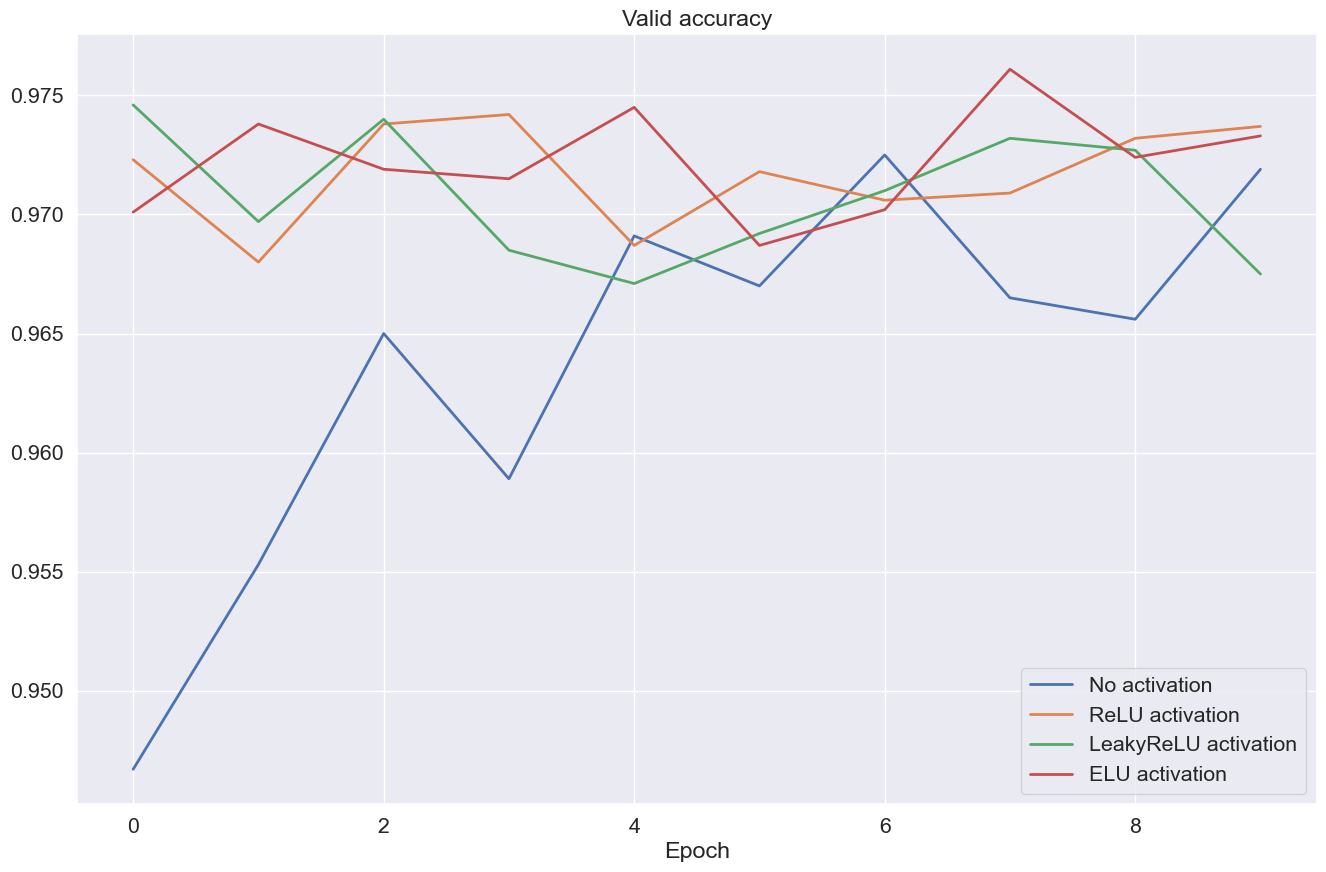

In [32]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy['valid'], label="No activation", linewidth=2)
plt.plot(range(max_epochs), ReLU_accuracy['valid'], label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), LeakyReLU_accuracy['valid'], label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), ELU_accuracy['valid'], label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

In [35]:
ReLU_accuracy['valid']

[0.9723, 0.968, 0.9738, 0.9742, 0.9687, 0.9718, 0.9706, 0.9709, 0.9732, 0.9737]

**Вопрос 4.** Какая из активаций показала наивысший `accuracy` к концу обучения?

**Ответ:** наивысший `accuracy` к концу обучения показала ReLU - 0,9737

## Часть 2.2 Сверточные нейронные сети

### Ядра
Сначала немного поработам с самим понятием ядра свёртки.

In [ ]:
!wget https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg -O sample_photo.jpg

In [ ]:
import cv2

sns.set(style="white")
img = cv2.imread("sample_photo.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(RGB_img)
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

In [ ]:
conv_1 = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])  # A
conv_2 = np.array([[0, 1, 0], [0, -2, 0], [0, 1, 0]])  # Б
conv_3 = np.array([[0, 0, 0], [1, -2, 1], [0, 0, 0]])  # В
conv_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])  # Г
conv_5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])  # Д
conv_6 = np.array([[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]])  # E

In [ ]:
img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
kernel = torch.tensor(conv_6).reshape(1, 1, 3, 3).type(torch.float32)

kernel = kernel.repeat(3, 3, 1, 1)
img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size

result = F.conv2d(img_t, kernel)[0]  #

In [ ]:
img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
kernel = torch.tensor([
    [0, 0, 0],
    [1, -2, 1],
    [0, 0, 0]
]).reshape(1, 1, 3, 3).type(torch.float32)

kernel = kernel.repeat(3, 3, 1, 1)
img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size

result = F.conv2d(img_t, kernel)[0]  #

In [ ]:
plt.figure(figsize=(12, 8))
result_np = result.permute(1, 2, 0).numpy() / 256 / 3

plt.imshow(result_np)
plt.show()

**Вопрос 5.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

1) Размытие

2) Увеличение резкости

3) Тождественное преобразование

4) Выделение вертикальных границ

5) Выделение горизонтальных границ

6) Выделение границ

**Ответ:**

### Задание 8. Реализуйте LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool1 =  #YOUR CODE
        self.conv2 =  #YOUR CODE
        self.pool2 =  #YOUR CODE
        self.fc1 =  #YOUR CODE
        self.fc2 =  #YOUR CODE
        self.fc3 =  #YOUR CODE

    def forward(self, x):
        x =  #YOUR CODE. Apply layers created in __init__.
        ...
        return x

In [ ]:
model = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

### Задание 9. Обучите CNN
Используйте код обучения, который вы написали для полносвязной нейронной сети.

In [ ]:
#YOUR CODE

In [ ]:
lenet_accuracy = accuracy["valid"]

Сравним с предыдущем пунктом

In [ ]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.plot(range(max_epochs), lenet_accuracy, label="LeNet", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 6**
Какое `accuracy` получается после обучения с точностью до двух знаков после запятой?

**Ответ:**